# In this notebook we explore whether combining graph construction of two similar materials but different at crystal structure level would affect the performance of the model

Since ZrO2 and YSZ are different in a crystal level structure, they exhibit different flash sintering behaviors

**Loading the dataset, Categorize ZrO2 and YSZ as the same material type, combining their subgraph together in the graph construction to find its effects on model's learning performances**

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch_geometric.data import Data
from torch_geometric.utils import to_undirected
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from scripts.gnn import KneePointGCN, train, visualize_graph, plot_losses

In [ ]:
data_df = pd.read_csv('./data/master_dataframe.csv')
label_encoder = LabelEncoder()
scaler = MinMaxScaler()
data_df['Material'] = data_df['Material'].replace('ZrO2', 'YSZ')
data_df['Material_encoded'] = label_encoder.fit_transform(data_df['Material'])
print(pd.get_dummies(data_df['Material']))
data_df = pd.concat([data_df, pd.get_dummies(data_df['Material']).astype(float)], axis=1)

node_features = []
node_labels = []

for material, group_df in data_df.groupby('Material'):

    group_df = group_df.sort_values('Electric_Field(V/cm)').reset_index(drop=True)
    
    sub_node_features = group_df[['Al2O3', 'BaTiO3', 'CoMnO4', 'SiC', 'SrTiO3',
       'TiO2', 'Y2O3', 'YSZ', 'Electric_Field(V/cm)']].values
       
    sub_node_labels = group_df[['Knee_Temp(1000/T)', 'Knee_PW(mW/mm^3)']].values

    node_features.append(sub_node_features)
    node_labels.append(sub_node_labels)

node_features = np.concatenate(node_features, axis=0)
node_labels = np.concatenate(node_labels, axis=0)
    
print(node_features.shape)
print(node_labels.shape)

    Al2O3  BaTiO3  CoMnO4    SiC  SrTiO3   TiO2   Y2O3    YSZ
0    True   False   False  False   False  False  False  False
1    True   False   False  False   False  False  False  False
2   False    True   False  False   False  False  False  False
3   False    True   False  False   False  False  False  False
4   False    True   False  False   False  False  False  False
5   False    True   False  False   False  False  False  False
6   False   False    True  False   False  False  False  False
7   False   False    True  False   False  False  False  False
8   False   False    True  False   False  False  False  False
9   False   False    True  False   False  False  False  False
10  False   False   False   True   False  False  False  False
11  False   False   False  False    True  False  False  False
12  False   False   False  False    True  False  False  False
13  False   False   False  False    True  False  False  False
14  False   False   False  False   False   True  False  False
15  Fals

Split the dataset into train test validation dataset (64/16/20)

In [ ]:
train_features, test_features, train_labels, test_labels = train_test_split(node_features, node_labels, test_size=0.2, shuffle=True, random_state=5)
train_features, val_features, train_labels, val_labels = train_test_split(train_features, train_labels, test_size=0.2, shuffle=True, random_state=5)

scaler = MinMaxScaler()
scaler.fit(train_features[:, -1].reshape(-1, 1))

train_features[:, -1] = scaler.transform(train_features[:, -1].reshape(-1, 1)).ravel()
val_features[:, -1]   = scaler.transform(val_features[:, -1].reshape(-1, 1)).ravel()
test_features[:, -1]  = scaler.transform(test_features[:, -1].reshape(-1, 1)).ravel()

train_features = torch.from_numpy(train_features).float()
train_labels   = torch.from_numpy(train_labels).float()

val_features   = torch.from_numpy(val_features).float()
val_labels     = torch.from_numpy(val_labels).float()

test_features  = torch.from_numpy(test_features).float()
test_labels    = torch.from_numpy(test_labels).float()

Construct subgraphs based on the material type of the dataset, forming a linear graph, edges are connected based on the electric field value.

In [ ]:
train_edges = []
test_edges = []
val_edges = []

sorted_materials = []
# create train_edges_index
for i in range(len(train_features)):
    material = train_features[i][:-1]
    e = train_features[i][-1].item()
    same_materials = []
    seen = False
    for m in sorted_materials:
        if torch.equal(m, material):
            seen = True
            break
    if not seen:
        for j in range(i, len(train_features)):
            if train_features[j][-1].item() != e and torch.equal(material, train_features[j][:-1]):
                same_materials.append([j, train_features[j][-1].item()])
        same_materials.append([i, e])
        sorted_materials.append(material)
    
    sorted_based_on_electricfield = sorted(same_materials, key=lambda a: a[1])

    for n in range(len(sorted_based_on_electricfield) - 1):
        train_edges.append([sorted_based_on_electricfield[n][0], sorted_based_on_electricfield[n + 1][0]])


sorted_materials = []
# create val_edges_index
for i in range(len(val_features)):
    material = val_features[i][:-1]
    e = val_features[i][-1].item()
    same_materials = []
    seen = False
    for m in sorted_materials:
        if torch.equal(m, material):
            seen = True
            break
    if not seen:
        for j in range(i, len(val_features)):
            if val_features[j][-1].item() != e and torch.equal(material, val_features[j][:-1]):
                same_materials.append([j, val_features[j][-1].item()])
        same_materials.append([i, e])
        sorted_materials.append(material)
    
    sorted_based_on_electricfield = sorted(same_materials, key=lambda a: a[1])

    for n in range(len(sorted_based_on_electricfield) - 1):
        val_edges.append([sorted_based_on_electricfield[n][0], sorted_based_on_electricfield[n + 1][0]])


sorted_materials = []
# create test_edges_index
for i in range(len(test_features)):
    material = test_features[i][:-1]
    e = test_features[i][-1].item()
    same_materials = []
    seen = False
    for m in sorted_materials:
        if torch.equal(m, material):
            seen = True
            break
    if not seen:
        for j in range(i, len(test_features)):
            if test_features[j][-1].item() != e and torch.equal(material, test_features[j][:-1]):
                same_materials.append([j, test_features[j][-1].item()])
        same_materials.append([i, e])
        sorted_materials.append(material)
    
    sorted_based_on_electricfield = sorted(same_materials, key=lambda a: a[1])

    for n in range(len(sorted_based_on_electricfield) - 1):
        test_edges.append([sorted_based_on_electricfield[n][0], sorted_based_on_electricfield[n + 1][0]])

train_edges  = to_undirected(torch.tensor(train_edges).t())
test_edges = to_undirected(torch.tensor(test_edges).t())
val_edges = to_undirected(torch.tensor(val_edges).t())


Create Train Validation Test dataloader

In [ ]:
train_data = Data(x=train_features, edge_index=train_edges, y=train_labels)
val_data = Data(x=val_features, edge_index=val_edges, y=val_labels)
test_data = Data(x=test_features, edge_index=test_edges, y= test_labels)

Visualize Constructed graphs

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]


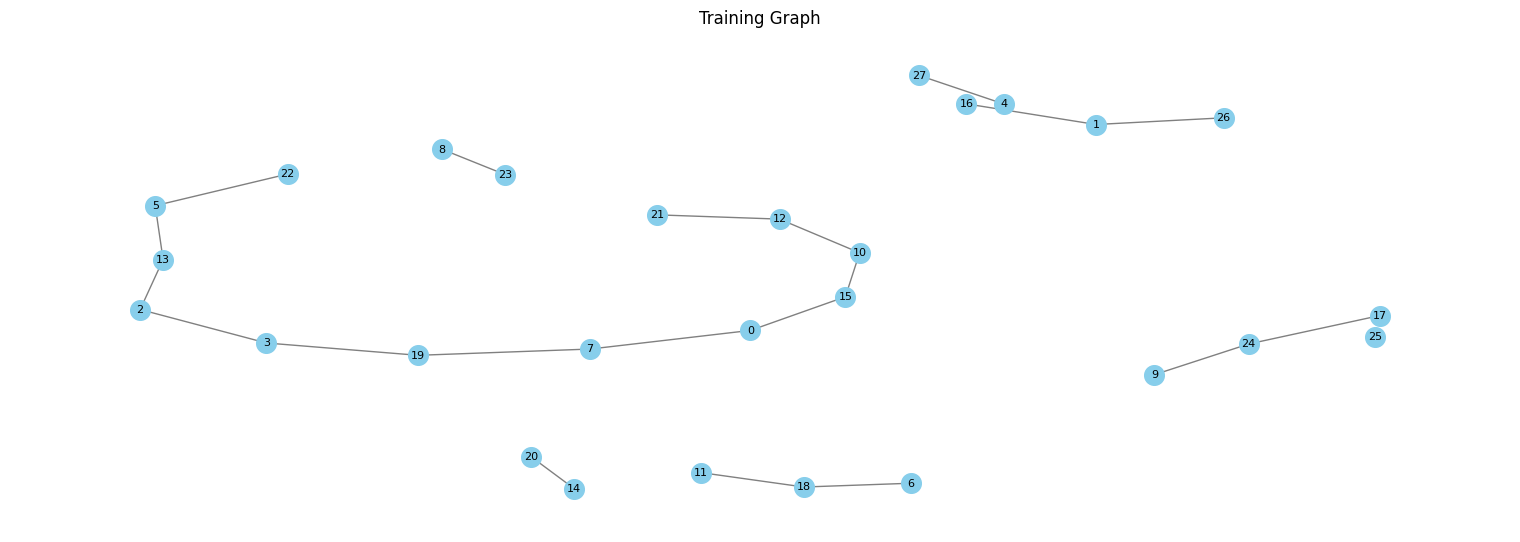

[0, 1, 2, 3, 4, 5, 6, 7, 8]


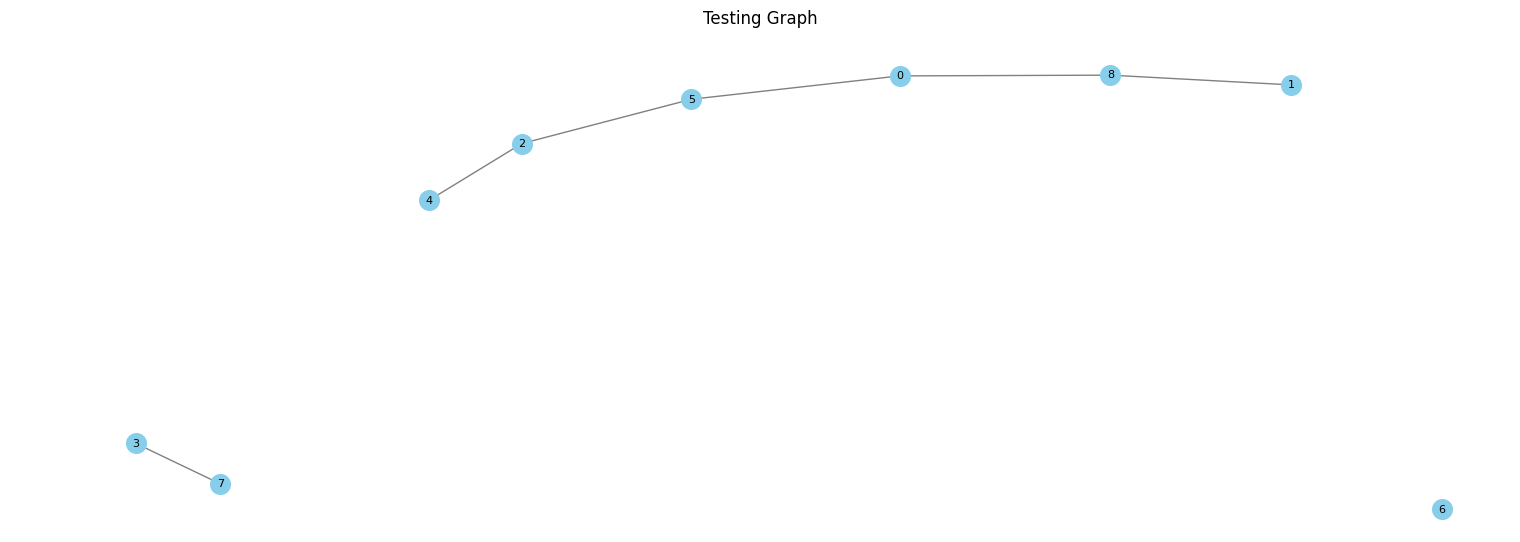

[0, 1, 2, 3, 4, 5, 6]


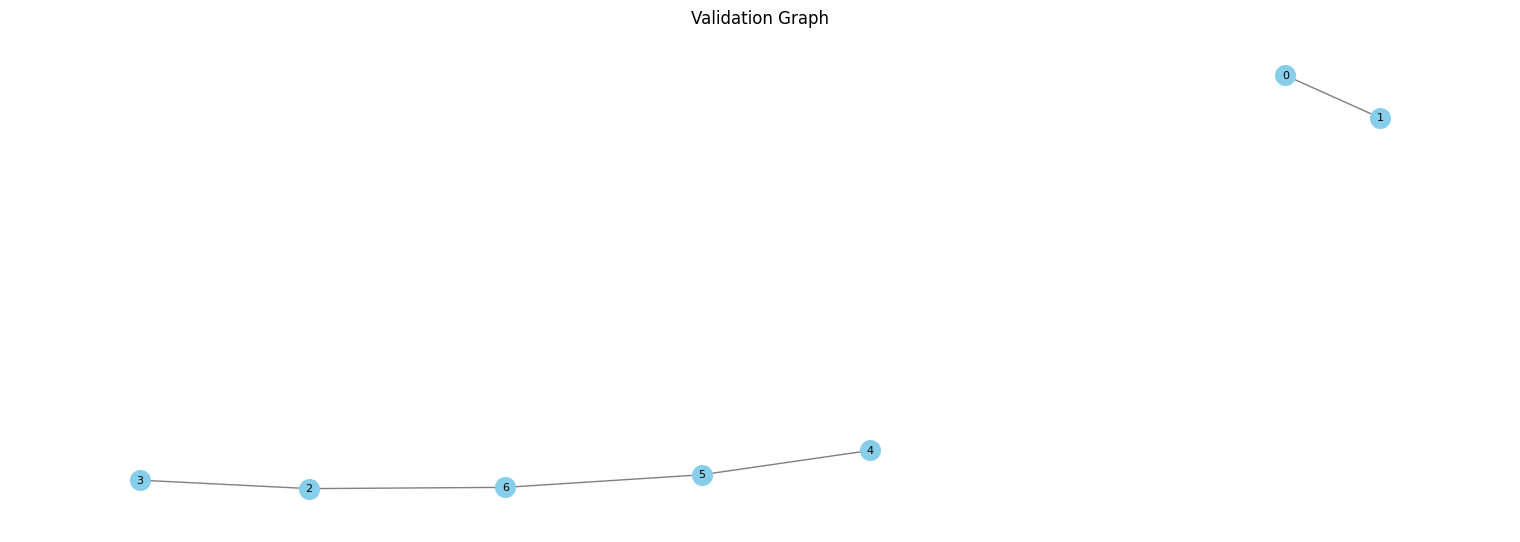

In [ ]:
# Visualizing Train Graph
visualize_graph(train_data, title="Training Graph")

# Visualizing Test Graph
visualize_graph(test_data, title="Testing Graph")

visualize_graph(val_data, title="Validation Graph")

### Train the model with combined ZrO2 and YSZ subgraphs, evaluate loss & accuracy

Epoch 1/350, Train Loss: 16.669139862060547, Train Accuracy: -3.8474502563476562%
Val Loss: 11.048789024353027, Val Accuracy: -3.2708358764648438%
Epoch 2/350, Train Loss: 16.65043067932129, Train Accuracy: -2.8142776489257812%
Val Loss: 11.032238960266113, Val Accuracy: -2.3810348510742188%
Epoch 3/350, Train Loss: 16.63362693786621, Train Accuracy: -2.0247650146484375%
Val Loss: 11.01385498046875, Val Accuracy: -1.5558547973632812%
Epoch 4/350, Train Loss: 16.617061614990234, Train Accuracy: -1.34375%
Val Loss: 10.994303703308105, Val Accuracy: -0.8445205688476562%
Epoch 5/350, Train Loss: 16.59972381591797, Train Accuracy: -0.7969818115234375%
Val Loss: 10.973759651184082, Val Accuracy: -0.1854705810546875%
Epoch 6/350, Train Loss: 16.580944061279297, Train Accuracy: -0.26220703125%
Val Loss: 10.951202392578125, Val Accuracy: 0.54376220703125%
Epoch 7/350, Train Loss: 16.5598201751709, Train Accuracy: 0.3362884521484375%
Val Loss: 10.926203727722168, Val Accuracy: 1.3615951538085938

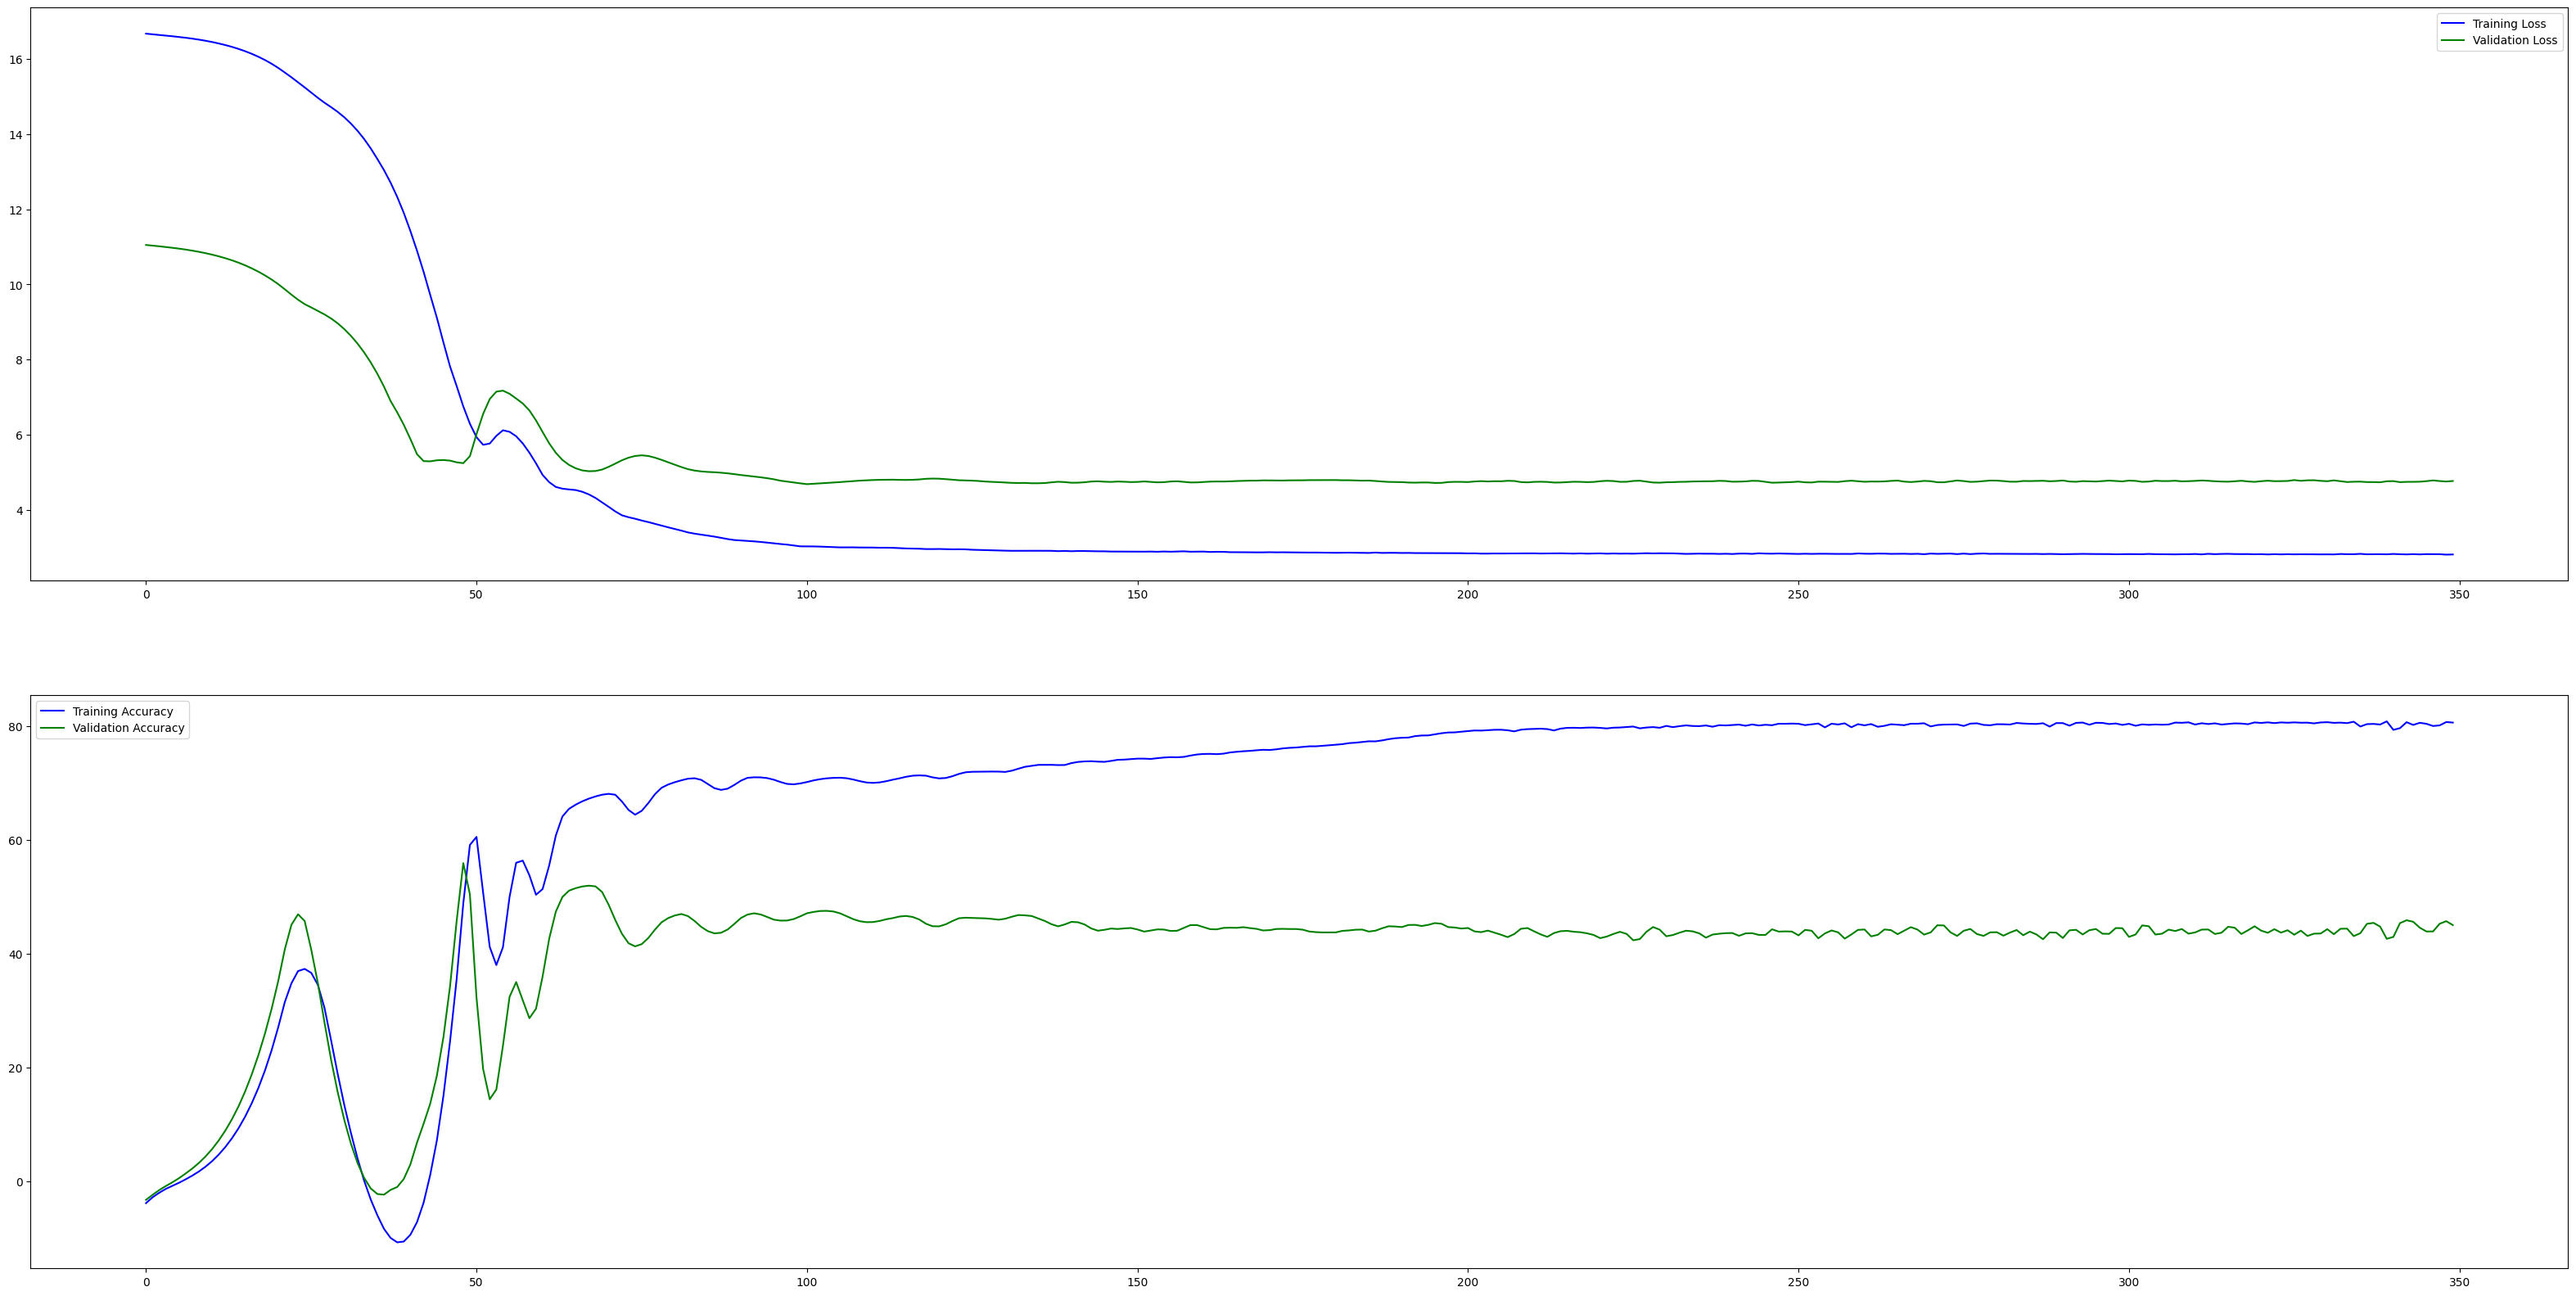

In [ ]:
# Train the model
model = KneePointGCN(features=9)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
loss_fn = nn.L1Loss()
epochs = 350
hist = train(model=model, train_data=train_data, val_data=val_data, test_data=test_data, optimizer=optimizer, loss_fn=loss_fn, epochs=epochs)
plot_losses(training_losses=hist['train_losses'], training_accuracies=hist['train_accuracies'], test_accuracies=hist['test_accuracies'], test_losses=hist['test_losses'], val_accuracies=hist['val_accuracies'], val_losses=hist['val_losses'], epochs=epochs, save_path='/home/sgl57/CSE_MSE_RXF131/cradle-members/mds3/sgl57/24-ceramics-rishi/topics/GNN')

By combining ZrO2 and YSZ subgraphs, the model's initial results has shown a decrease in performance.

Results can also caused by the fact that YSZ and ZrO2 consists the majority of the dataset, combining their subgraph likely has the effects of overfitting to this particular subgraph and lose the overall generality of the model, therefore deteriorates overall performance.